<h1> Описание проекта </h1>

Интернет-магазин собирает данные о покупках клиентов и их взаимодействии с маркетинговыми рассылками. Для повышения эффективности маркетинговых кампаний необходимо выявлять пользователей, которые с высокой вероятностью совершат покупку в ближайшем будущем.
В рамках проекта будет построена модель машинного обучения, способная прогнозировать вероятность совершения клиентом покупки в течение следующих 90 дней на основе истории покупок и взаимодействий с рекламными сообщениями.

Цель проекта
Разработать модель бинарной классификации для прогнозирования вероятности покупки клиента в течение последующих 90 дней.


<h3> Задачи проекта </h3>
* изучить структуру и качество исходных данных;
* выполнить исследовательский анализ данных;
* подготовить данные для моделирования;
* разработать информативные признаки на основе истории покупок и маркетинговых рассылок;
* обучить и сравнить несколько моделей классификации;
* подобрать оптимальные параметры модели;
* оценить качество модели с использованием метрики ROC-AUC;
* выполнить тестирование и интерпретацию результатов.


<h3> Используемые данные </h3>
В проекте используются данные о покупках клиентов интернет-магазина, история маркетинговых рассылок, информация о взаимодействии пользователей с сообщениями, а также целевой признак, отражающий факт совершения покупки в целевом периоде.


<h3> План выполнения проекта </h3>
1. Загрузка и первичное изучение данных.
2. Исследовательский анализ данных.
3. Предобработка данных.
4. Создание и отбор признаков.
5. Подготовка обучающей выборки.
6. Обучение и сравнение моделей машинного обучения.
7. Подбор гиперпараметров лучшей модели.
8. Оценка качества модели на тестовых данных.
9. Формулировка выводов и рекомендаций.

<h3> Ожидаемый результат </h3>
В результате проекта будет получена модель машинного обучения, позволяющая оценивать вероятность совершения клиентом покупки в течение следующих 90 дней. Полученные прогнозы могут быть использованы для повышения эффективности маркетинговых коммуникаций и более точного таргетирования рекламных кампаний.


<h1>Загрузка и обзор данных</h1>

In [71]:
#Необходимые импорты
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
import ast
from collections import Counter

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score, f1_score
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [72]:
data_path = 'filtered_data'

purchases = pd.read_csv(os.path.join(data_path, 'apparel-purchases.csv'))
messages = pd.read_csv(os.path.join(data_path, 'apparel-messages.csv'))
target = pd.read_csv(os.path.join(data_path, 'apparel-target_binary.csv'))
campaign_daily = pd.read_csv(os.path.join(data_path, 'full_campaign_daily_event.csv'))
campaign_channel = pd.read_csv(os.path.join(data_path, 'full_campaign_daily_event_channel.csv'))

In [73]:
#Функция для получения основной информации о датасетах


def dataframe_overview(df, name=None, head_rows=5):

    if name:
        print(f'\n{"=" * 20} {name} {"=" * 20}\n')

    print('Первые строки:')
    display(df.head(head_rows))

    print('\nИнформация о DataFrame:')
    display(df.dtypes)

    print('\nРазмер датасета:')
    print(df.shape)

    print('\nКоличество пропусков:')
    display(df.isna().sum())

    print('\nКоличество явных дубликатов:')
    print(df.duplicated().sum())

In [74]:
#Первичный обзор данных
dataframe_overview(purchases, 'Purchases')
dataframe_overview(messages, 'Messages')
dataframe_overview(target, 'Target')
dataframe_overview(campaign_daily, 'Campaign Daily')
dataframe_overview(campaign_channel, 'Campaign Channel')


==================== Purchases ====================

Первые строки:


,client_id,quantity,price,category_ids,date,message_id
0,1515915625468169594,1,1999.0,"['4', '28', '57', '431']",2022-05-16,1515915625468169594-4301-627b661e9736d
1,1515915625468169594,1,2499.0,"['4', '28', '57', '431']",2022-05-16,1515915625468169594-4301-627b661e9736d
2,1515915625471138230,1,6499.0,"['4', '28', '57', '431']",2022-05-16,1515915625471138230-4437-6282242f27843
3,1515915625471138230,1,4999.0,"['4', '28', '244', '432']",2022-05-16,1515915625471138230-4437-6282242f27843
4,1515915625471138230,1,4999.0,"['4', '28', '49', '413']",2022-05-16,1515915625471138230-4437-6282242f27843



Информация о DataFrame:


client_id         int64
quantity          int64
price           float64
category_ids     object
date             object
message_id       object
dtype: object


Размер датасета:
(202208, 6)

Количество пропусков:


...


Информация о DataFrame:


date                               object
bulk_campaign_id                    int64
count_click_email                   int64
count_click_mobile_push             int64
count_open_email                    int64
count_open_mobile_push              int64
count_purchase_email                int64
count_purchase_mobile_push          int64
count_soft_bounce_email             int64
count_subscribe_email               int64
count_unsubscribe_email             int64
nunique_click_email                 int64
nunique_click_mobile_push           int64
nunique_open_email                  int64
nunique_open_mobile_push            int64
nunique_purchase_email              int64
nunique_purchase_mobile_push        int64
nunique_soft_bounce_email           int64
nunique_subscribe_email             int64
nunique_unsubscribe_email           int64
count_hard_bounce_mobile_push       int64
count_send_mobile_push              int64
nunique_hard_bounce_mobile_push     int64
nunique_send_mobile_push          


Размер датасета:
(131072, 36)

Количество пропусков:


date                               0
bulk_campaign_id                   0
count_click_email                  0
count_click_mobile_push            0
count_open_email                   0
count_open_mobile_push             0
count_purchase_email               0
count_purchase_mobile_push         0
count_soft_bounce_email            0
count_subscribe_email              0
count_unsubscribe_email            0
nunique_click_email                0
nunique_click_mobile_push          0
nunique_open_email                 0
nunique_open_mobile_push           0
nunique_purchase_email             0
nunique_purchase_mobile_push       0
nunique_soft_bounce_email          0
nunique_subscribe_email            0
nunique_unsubscribe_email          0
count_hard_bounce_mobile_push      0
count_send_mobile_push             0
nunique_hard_bounce_mobile_push    0
nunique_send_mobile_push           0
count_hard_bounce_email            0
count_hbq_spam_email               0
count_send_email                   0
n


Количество явных дубликатов:
0


<div style="
    background-color: #F2ECFF;
    border-left: 6px solid #B89CFF;
    padding: 15px 18px;
    border-radius: 8px;
    font-size: 15px;
    line-height: 1.6;
">

<b>Промежуточный вывод</b><br><br>

На этапе загрузки данных были успешно импортированы пять таблиц, содержащие информацию о покупках клиентов, маркетинговых рассылках, целевом признаке и агрегированной статистике рекламных кампаний.

В ходе первичного обзора установлено, что пропуски отсутствуют во всех датасетах. Наибольший объем данных содержится в таблице <i>messages</i> (более 12,7 млн записей), отражающей историю взаимодействий клиентов с рассылками. Таблица <i>purchases</i> содержит более 202 тыс. записей о покупках товаров, а целевая выборка включает сведения о 49 849 клиентах.

В таблицах <i>purchases</i> и <i>messages</i> обнаружены явные дубликаты, требующие дополнительного анализа на следующем этапе. Остальные датасеты дубликатов не содержат.

Также установлено, что ряд признаков, связанных с датами и временем, загружены в формате <i>object</i> и потребуют приведения к соответствующим типам данных в рамках предобработки.

В целом данные успешно загружены и готовы к дальнейшему исследованию и подготовке.



</div>

<h1> Предобработка данных </h1>

In [75]:
print('PURCHASES')
display(purchases['date'].head())

print('\nMESSAGES')
display(messages[['date', 'created_at']].head())

print('\nCAMPAIGN DAILY')
display(campaign_daily['date'].head())

print('\nCAMPAIGN CHANNEL')
display(campaign_channel['date'].head())

PURCHASES


0    2022-05-16
1    2022-05-16
2    2022-05-16
3    2022-05-16
4    2022-05-16
Name: date, dtype: object


MESSAGES


,date,created_at
0,2022-05-19,2022-05-19 00:14:20
1,2022-05-19,2022-05-19 00:39:34
2,2022-05-19,2022-05-19 00:51:49
3,2022-05-19,2022-05-19 00:52:20
4,2022-05-19,2022-05-19 00:56:52



CAMPAIGN DAILY


0    2022-05-19
1    2022-05-19
2    2022-05-19
3    2022-05-19
4    2022-05-19
Name: date, dtype: object


CAMPAIGN CHANNEL


0    2022-05-19
1    2022-05-19
2    2022-05-19
3    2022-05-19
4    2022-05-19
Name: date, dtype: object

In [76]:
# Преобразуем столбцы с датами в верный формат - datetime

# PURCHASES
purchases['date'] = pd.to_datetime(purchases['date'])

# MESSAGES
messages['date'] = pd.to_datetime(messages['date'])
messages['created_at'] = pd.to_datetime(messages['created_at'])

# CAMPAIGN DAILY
campaign_daily['date'] = pd.to_datetime(campaign_daily['date'])

# CAMPAIGN CHANNEL
campaign_channel['date'] = pd.to_datetime(campaign_channel['date'])

# Проверим преобразование
print('PURCHASES:', purchases['date'].dtype)
print('MESSAGES date:', messages['date'].dtype)
print('MESSAGES created_at:', messages['created_at'].dtype)
print('CAMPAIGN DAILY:', campaign_daily['date'].dtype)
print('CAMPAIGN CHANNEL:', campaign_channel['date'].dtype)

PURCHASES: datetime64[ns]
MESSAGES date: datetime64[ns]
MESSAGES created_at: datetime64[ns]
CAMPAIGN DAILY: datetime64[ns]
CAMPAIGN CHANNEL: datetime64[ns]


In [77]:
# Дубликаты в purchases
display(
    purchases[purchases.duplicated()]
    .sort_values(['client_id', 'date'])
    .head(20)
)

# Дубликаты в messages
display(
    messages[messages.duplicated()]
    .sort_values(['client_id', 'created_at'])
    .head(20)
)

,client_id,quantity,price,category_ids,date,message_id
3698,1515915625468060902,1,1999.0,"['4', '28', '260', '420']",2022-05-27,1515915625468060902-4617-6290657dac196
3699,1515915625468060902,1,199.0,"['4', '27', '176', '458']",2022-05-27,1515915625468060902-4617-6290657dac196
81794,1515915625468061003,1,2100.0,"['4', '28', '249', '615']",2023-01-04,1515915625468061003-9148-63b54b04855a4
200016,1515915625468061100,1,1049.0,"['4', '27', '1828', '5717']",2024-02-10,1515915625468061100-14623-65c5c55eeb9e0
95807,1515915625468061170,1,7.0,[],2023-03-26,1515915625468061170-11144-641ad2cda77a2
95809,1515915625468061170,1,2699.0,"['2', '18', '258', '441']",2023-03-26,1515915625468061170-11144-641ad2cda77a2
96091,1515915625468061170,1,2199.0,"['4', '28', '260', '420']",2023-03-29,1515915625468061170-11208-6423f082d2fcb
96093,1515915625468061170,1,1609.0,"['4', '28', '260', '420']",2023-03-29,1515915625468061170-11208-6423f082d2fcb
96095,1515915625468061170,1,2195.0,"['4', '28', '260', '420']",2023-03-29,1515915625468061170-11208-6423f082d2fcb
96096,1515915625468061170,1,2199.0,"['4', '28', '260', '420']",2023-03-29,1515915625468061170-11208-6423f082d2fcb


,bulk_campaign_id,client_id,message_id,event,channel,date,created_at
5109180,12566,1515915625468061003,1515915625468061003-12566-646330138e845,click,email,2023-05-16,2023-05-16 13:29:21
5609618,13324,1515915625468061100,1515915625468061100-13324-648403889887c,open,mobile_push,2023-06-10,2023-06-10 05:10:37
5651748,13308,1515915625468061100,1515915625468061100-13308-648457e227c2d,open,mobile_push,2023-06-10,2023-06-10 11:04:06
5656176,13332,1515915625468061100,1515915625468061100-13332-64848a3038e23,open,mobile_push,2023-06-10,2023-06-10 14:36:00
5696500,13342,1515915625468061100,1515915625468061100-13342-648873a5b5cab,open,mobile_push,2023-06-13,2023-06-13 14:19:42
5721086,13351,1515915625468061100,1515915625468061100-13351-6489abdbdaeb6,open,mobile_push,2023-06-14,2023-06-14 12:04:50
5823341,13379,1515915625468061100,1515915625468061100-13379-6492ca5caf394,open,mobile_push,2023-06-21,2023-06-21 11:01:47
2693607,8131,1515915625468061994,1515915625468061994-8131-637f837a209a8,click,mobile_push,2022-11-24,2022-11-24 15:03:57
2743828,8169,1515915625468061994,1515915625468061994-8169-6381ebae30f8c,click,mobile_push,2022-11-26,2022-11-26 10:49:25
3932305,9856,1515915625468062158,1515915625468062158-9856-63dcff9b312ab,click,email,2023-02-07,2023-02-07 02:57:00


In [78]:
print('PURCHASES')
print(f'Количество дубликатов: {purchases.duplicated().sum()}')
print(f'Доля дубликатов: {purchases.duplicated().mean():.2%}')

print('\nMESSAGES')
print(f'Количество дубликатов: {messages.duplicated().sum()}')
print(f'Доля дубликатов: {messages.duplicated().mean():.2%}')

PURCHASES
Количество дубликатов: 73020
Доля дубликатов: 36.11%

MESSAGES
Количество дубликатов: 48610
Доля дубликатов: 0.38%


In [79]:
purchases_duplicates = purchases[
    purchases.duplicated(keep=False)
].sort_values(list(purchases.columns))

messages_duplicates = messages[
    messages.duplicated(keep=False)
].sort_values(list(messages.columns))

print('Повторяющихся строк в purchases:',
      purchases_duplicates.shape[0])

print('Повторяющихся строк в messages:',
      messages_duplicates.shape[0])

Повторяющихся строк в purchases: 131683
Повторяющихся строк в messages: 94519


In [80]:
print('PURCHASES')
print('client_id:', purchases['client_id'].nunique())
print('message_id:', purchases['message_id'].nunique())

print('\nMESSAGES')
print('client_id:', messages['client_id'].nunique())
print('message_id:', messages['message_id'].nunique())
print('bulk_campaign_id:', messages['bulk_campaign_id'].nunique())

print('\nTARGET')
print('client_id:', target['client_id'].nunique())

PURCHASES
client_id: 49849
message_id: 50204

MESSAGES
client_id: 53329
message_id: 9061667
bulk_campaign_id: 2709

TARGET
client_id: 49849


<div style="
    background-color: #F2ECFF;
    border-left: 6px solid #B89CFF;
    padding: 15px 18px;
    border-radius: 8px;
    font-size: 15px;
    line-height: 1.6;
">

<b>Промежуточный вывод: предобработка данных</b><br><br>

1. Все столбцы с датами были приведены к типу <i>datetime</i>:
   - <b>purchases.date</b>
   - <b>messages.date</b>, <b>messages.created_at</b>
   - <b>campaign_daily.date</b>
   - <b>campaign_channel.date</b>

2. Пропуски в данных отсутствуют во всех таблицах, поэтому отдельная обработка пропусков не требуется.

3. Проверка дубликатов показала:
   - В таблице <b>purchases</b> 73 020 полных дубликатов (≈36%), большинство связано с повторяющимися заказами одного клиента по одному message_id.  
   - В таблице <b>messages</b> 48 610 дубликатов (≈0.38%), что является крайне малой долей и, вероятно, связано с повторной регистрацией событий для одного сообщения.

4. Проверка уникальности ключей:
   - <b>purchases</b>: 49 849 уникальных client_id, 50 204 уникальных message_id.
   - <b>messages</b>: 53 329 уникальных client_id, 9 061 667 уникальных message_id, 2 709 уникальных bulk_campaign_id.
   - <b>target</b>: 49 849 уникальных client_id.

5. Вывод:
   - Данные готовы к дальнейшей обработке и анализу.  
   - Дубликаты в <b>purchases</b> требуют внимательного изучения на этапе генерации признаков.  
   - Дубликаты в <b>messages</b> можно учитывать как отдельные события при создании признаков.  

</div>

In [81]:
# Создаём копию датасета, чтобы не перезаписывать оригинал
purchases_clean = purchases.copy()

purchases_clean = purchases_clean.groupby(
    ['client_id', 'message_id', 'date'],
    as_index=False
).agg({
    'quantity': 'sum',
    'price': 'sum',
    'category_ids': lambda x: list(x)  
})

# Проверяем 
print('Оригинальный purchases:', purchases.shape)
print('После обработки дубликатов:', purchases_clean.shape)
display(purchases_clean.head(10))

Оригинальный purchases: (202208, 6)
После обработки дубликатов: (60312, 6)


,client_id,message_id,date,quantity,price,category_ids
0,1515915625468060902,1515915625468060902-4617-6290657dac196,2022-05-27,7,6993.0,"[['4', '27', '176', '458'], ['4', '28', '260',..."
1,1515915625468061003,1515915625468061003-9148-63b54b04855a4,2023-01-04,7,16235.0,"[['4', '28', '249', '615'], ['4', '28', '249',..."
2,1515915625468061099,1515915625468061099-4439-62834141aa538,2022-05-17,1,299.0,"[['4', '28', '290', '424']]"
3,1515915625468061100,1515915625468061100-14623-65c5c55eeb9e0,2024-02-10,2,2098.0,"[['4', '27', '1828', '5717'], ['4', '27', '182..."
4,1515915625468061170,1515915625468061170-11144-641ad2cda77a2,2023-03-26,4,5412.0,"[[], [], ['2', '18', '258', '441'], ['2', '18'..."
5,1515915625468061170,1515915625468061170-11208-6423f082d2fcb,2023-03-29,12,25192.0,"[['4', '28', '260', '420'], ['4', '28', '260',..."
6,1515915625468061170,1515915625468061170-13157-6483192913837,2023-06-17,3,2997.0,"[['4', '28', '244', '432'], ['4', '28', '244',..."
7,1515915625468061514,1515915625468061514-5707-62e3823619b1f,2022-07-30,1,999.0,"[['4', '28', '239', '418']]"
8,1515915625468061877,1515915625468061877-5922-62ff354653bfd,2022-08-19,1,1499.0,"[['5562', '5630', '5699', '1829']]"
9,1515915625468061975,1515915625468061975-5662-62e0e6198eac6,2022-07-27,1,299.0,"[['4', '5837', '5838', '1848']]"


In [82]:
# Копия исходного датасета
messages_clean = messages.copy()


duplicate_mask = messages_clean.duplicated(keep=False)
print('Полные дубликаты строк в messages:', duplicate_mask.sum())


display(messages_clean[duplicate_mask].head(10))

Полные дубликаты строк в messages: 94519


,bulk_campaign_id,client_id,message_id,event,channel,date,created_at
964231,5723,1515915625554535987,1515915625554535987-5723-62e2af08e00da,click,mobile_push,2022-07-28,2022-07-28 15:58:56
964232,5723,1515915625554535987,1515915625554535987-5723-62e2af08e00da,click,mobile_push,2022-07-28,2022-07-28 15:58:56
966465,5723,1515915625483569932,1515915625483569932-5723-62e2af0790ad5,click,mobile_push,2022-07-28,2022-07-28 16:07:12
966466,5723,1515915625483569932,1515915625483569932-5723-62e2af0790ad5,click,mobile_push,2022-07-28,2022-07-28 16:07:12
967281,5723,1515915625736038297,1515915625736038297-5723-62e2af0a17cba,click,mobile_push,2022-07-28,2022-07-28 16:09:56
967282,5723,1515915625736038297,1515915625736038297-5723-62e2af0a17cba,click,mobile_push,2022-07-28,2022-07-28 16:09:56
967566,5723,1515915625753898206,1515915625753898206-5723-62e2af0a21ecd,click,mobile_push,2022-07-28,2022-07-28 16:12:24
967567,5723,1515915625753898206,1515915625753898206-5723-62e2af0a21ecd,click,mobile_push,2022-07-28,2022-07-28 16:12:24
967903,5723,1515915625626349443,1515915625626349443-5723-62e2af09c0fd3,click,mobile_push,2022-07-28,2022-07-28 16:15:02
967904,5723,1515915625626349443,1515915625626349443-5723-62e2af09c0fd3,click,mobile_push,2022-07-28,2022-07-28 16:15:02


In [83]:
# удаляем полные дубликаты
messages_clean = messages_clean.drop_duplicates()

print('До удаления:', messages.shape)
print('После удаления:', messages_clean.shape)

print('Осталось дубликатов:',
      messages_clean.duplicated().sum())

До удаления: (12739798, 7)
После удаления: (12691188, 7)
Осталось дубликатов: 0


In [84]:
messages_clean['event'].value_counts()
messages_clean['channel'].value_counts()

channel
mobile_push    7470472
email          5220716
Name: count, dtype: int64

In [85]:
print('EVENT')
display(messages_clean['event'].value_counts())

print('\nCHANNEL')
display(messages_clean['channel'].value_counts())

EVENT


event
send           9058174
open           3052481
click           483326
purchase         62593
hard_bounce      19763
soft_bounce      10582
unsubscribe       2833
hbq_spam           823
complain           527
subscribe           85
close                1
Name: count, dtype: int64


CHANNEL


channel
mobile_push    7470472
email          5220716
Name: count, dtype: int64

<div style="
    background-color: #F2ECFF;
    border-left: 6px solid #B89CFF;
    padding: 15px 18px;
    border-radius: 8px;
    font-size: 15px;
    line-height: 1.6;
">

<b>Промежуточный вывод</b><br><br>

В рамках этапа предобработки были проверены пропущенные значения, типы данных и дубликаты во всех таблицах проекта.

Проверка показала отсутствие пропущенных значений во всех датасетах, поэтому дополнительная обработка пропусков не потребовалась.

Для корректной работы с временными данными столбцы, содержащие даты и время, были приведены к типу <i>datetime</i>. Преобразование выполнено для признаков <i>date</i> в таблицах <i>purchases</i>, <i>messages</i>, <i>campaign_daily</i> и <i>campaign_channel</i>, а также для признака <i>created_at</i> в таблице <i>messages</i>.

При анализе дубликатов были выявлены различия между таблицами. В таблице <i>purchases</i> обнаружено значительное количество повторяющихся записей. Для сохранения информации о покупках данные были агрегированы по клиенту, идентификатору сообщения и дате покупки с суммированием количества товаров и стоимости заказа. В результате количество записей сократилось с 202 208 до 60 312.

В таблице <i>messages</i> были обнаружены полностью совпадающие строки. После проверки структуры дубликатов было установлено, что они представляют собой повторяющиеся записи одних и тех же событий. Полные дубликаты были удалены, в результате чего размер таблицы уменьшился с 12 739 798 до 12 691 188 строк. Повторная проверка подтвердила отсутствие оставшихся явных дубликатов.

Дополнительно были проверены категориальные признаки <i>event</i> и <i>channel</i>. Неявные дубликаты, связанные с различиями в регистре или написании категорий, обнаружены не были.

Таким образом, данные были подготовлены для дальнейшего исследовательского анализа и построения признаков.

</div>

<h1>Исследовательский анализ</h1>

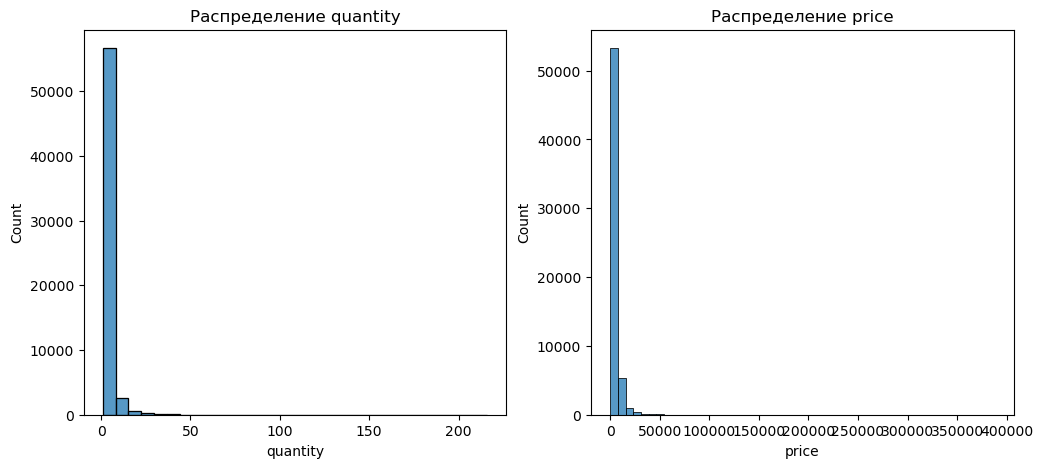

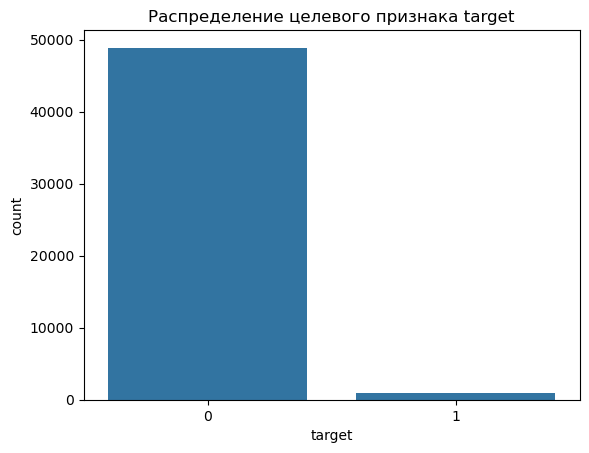

In [86]:
# Purchases: quantity и price
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(purchases_clean['quantity'], bins=30, kde=False)
plt.title('Распределение quantity')

plt.subplot(1,2,2)
sns.histplot(purchases_clean['price'], bins=50, kde=False)
plt.title('Распределение price')
plt.show()

# Target: доля покупок
sns.countplot(x='target', data=target)
plt.title('Распределение целевого признака target')
plt.show()

In [87]:
display(
    purchases_clean[['quantity', 'price']]
    .describe(percentiles=[0.5, 0.9, 0.95, 0.99])
)

,quantity,price
count,60312.000000,60312.000000
mean,3.374436,4000.781155
std,4.038003,5753.727575
min,1.000000,1.000000
50%,2.000000,2499.000000
90%,6.000000,8398.000000
95%,10.000000,11994.000000
99%,18.000000,24038.720000
max,216.000000,387583.000000


In [88]:
target['target'].value_counts(normalize=True)

target
0    0.980722
1    0.019278
Name: proportion, dtype: float64

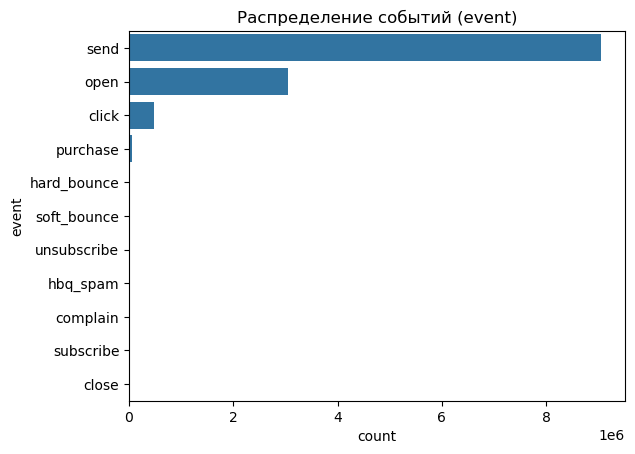

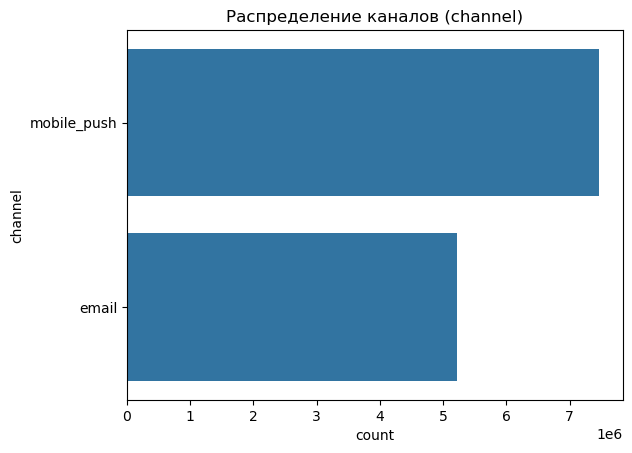

In [89]:
# События
sns.countplot(y='event', data=messages_clean, order=messages_clean['event'].value_counts().index)
plt.title('Распределение событий (event)')
plt.show()

# Каналы
sns.countplot(y='channel', data=messages_clean, order=messages_clean['channel'].value_counts().index)
plt.title('Распределение каналов (channel)')
plt.show()

In [90]:
messages_clean['event'].value_counts(normalize=True) * 100

event
send           71.373728
open           24.051972
click           3.808359
purchase        0.493200
hard_bounce     0.155722
soft_bounce     0.083381
unsubscribe     0.022323
hbq_spam        0.006485
complain        0.004152
subscribe       0.000670
close           0.000008
Name: proportion, dtype: float64

In [91]:
messages_clean['channel'].value_counts(normalize=True) * 100

channel
mobile_push    58.863457
email          41.136543
Name: proportion, dtype: float64

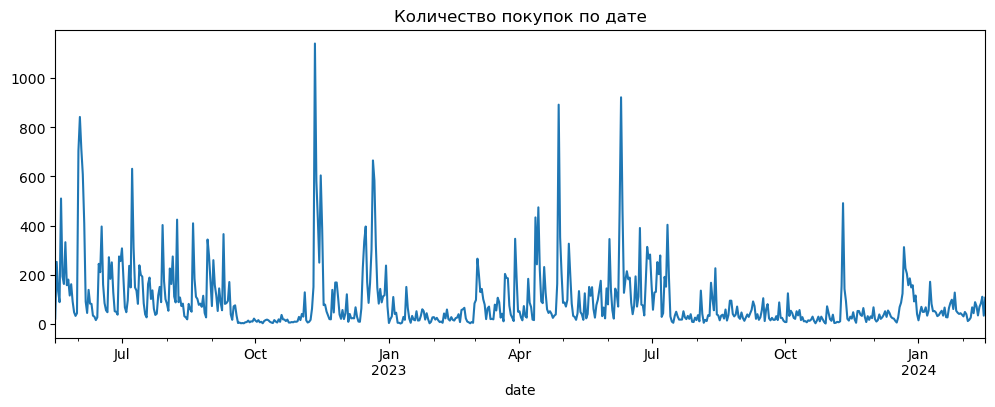

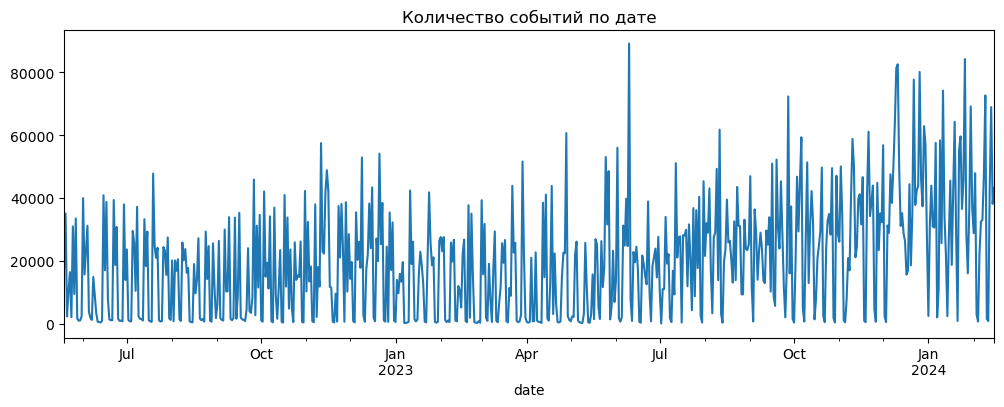

In [92]:
# Количество покупок по дате
purchases_clean.groupby('date').size().plot(figsize=(12,4), title='Количество покупок по дате')
plt.show()

# Количество событий по дате
messages_clean.groupby('date').size().plot(figsize=(12,4), title='Количество событий по дате')
plt.show()

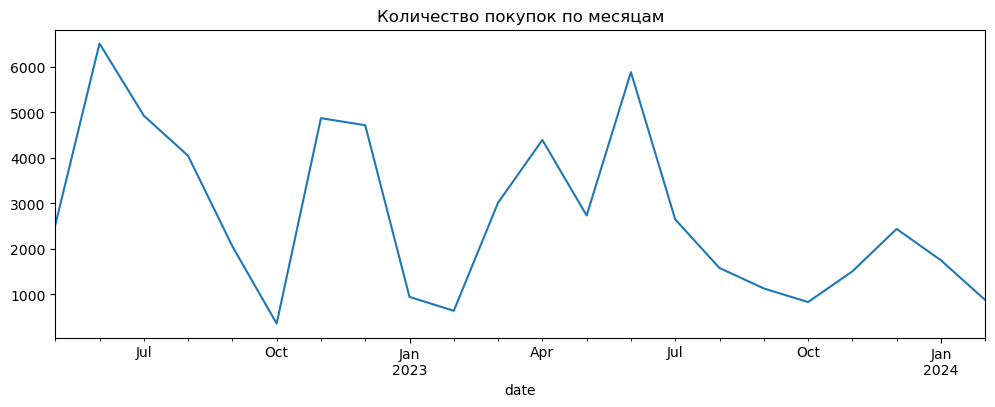

In [93]:
purchases_monthly = (
    purchases_clean
    .groupby(purchases_clean['date'].dt.to_period('M'))
    .size()
)

purchases_monthly.plot(
    figsize=(12,4),
    title='Количество покупок по месяцам'
)
plt.show()

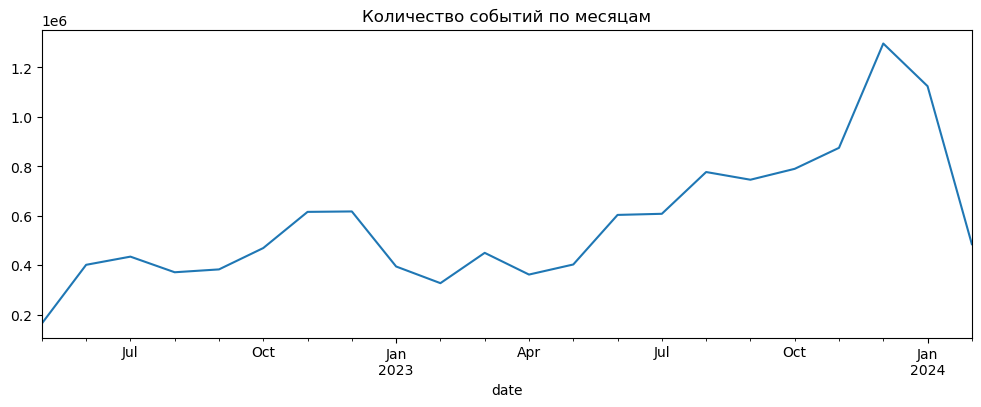

In [94]:
messages_monthly = (
    messages_clean
    .groupby(messages_clean['date'].dt.to_period('M'))
    .size()
)

messages_monthly.plot(
    figsize=(12,4),
    title='Количество событий по месяцам'
)
plt.show()

In [95]:
monthly_compare = pd.DataFrame({
    'purchases': purchases_clean.groupby(
        purchases_clean['date'].dt.to_period('M')
    ).size(),

    'messages': messages_clean.groupby(
        messages_clean['date'].dt.to_period('M')
    ).size()
})

monthly_compare

,purchases,messages
date,,
2022-05,2517,163679
2022-06,6509,401191
2022-07,4925,434278
2022-08,4042,371067
2022-09,2054,382629
2022-10,357,469053
2022-11,4869,615352
2022-12,4714,617093
2023-01,942,394360


In [96]:
print('Purchases:')
print(purchases_clean['date'].min())
print(purchases_clean['date'].max())

print()

print('Messages:')
print(messages_clean['date'].min())
print(messages_clean['date'].max())

Purchases:
2022-05-16 00:00:00
2024-02-16 00:00:00

Messages:
2022-05-19 00:00:00
2024-02-15 00:00:00


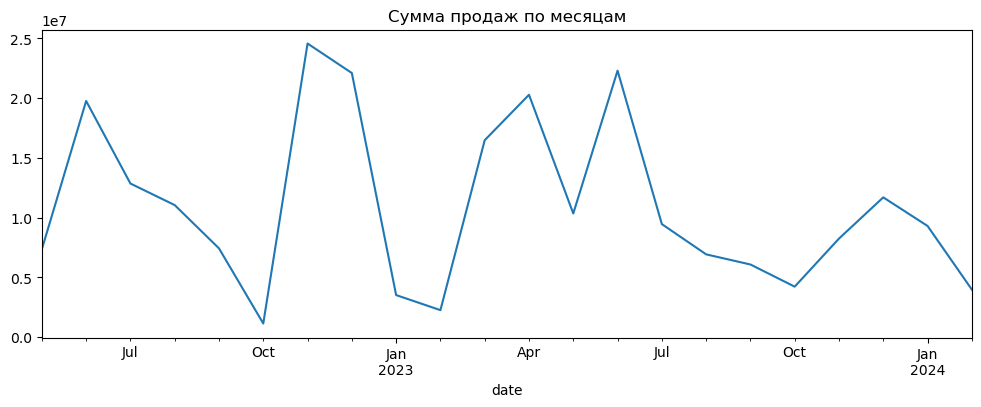

In [97]:
monthly_revenue = (
    purchases_clean
    .groupby(purchases_clean['date'].dt.to_period('M'))['price']
    .sum()
)

monthly_revenue.plot(
    figsize=(12,4),
    title='Сумма продаж по месяцам'
)
plt.show()

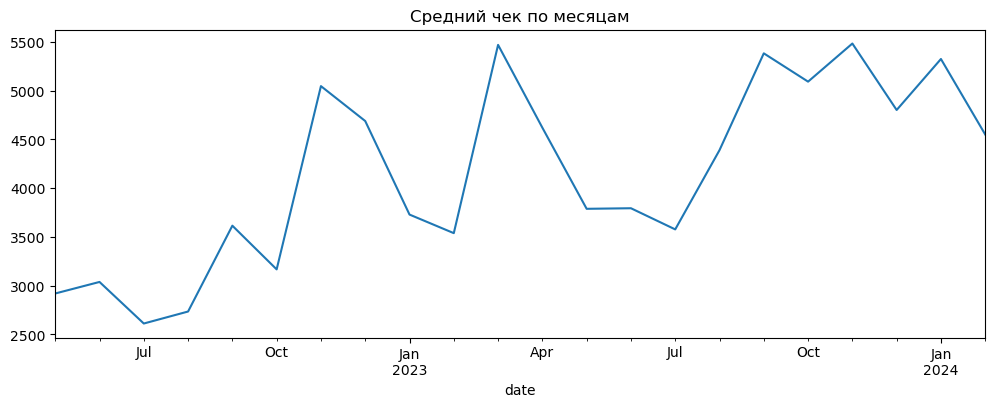

In [98]:
monthly_avg_check = (
    purchases_clean
    .groupby(purchases_clean['date'].dt.to_period('M'))['price']
    .mean()
)

monthly_avg_check.plot(
    figsize=(12,4),
    title='Средний чек по месяцам'
)
plt.show()

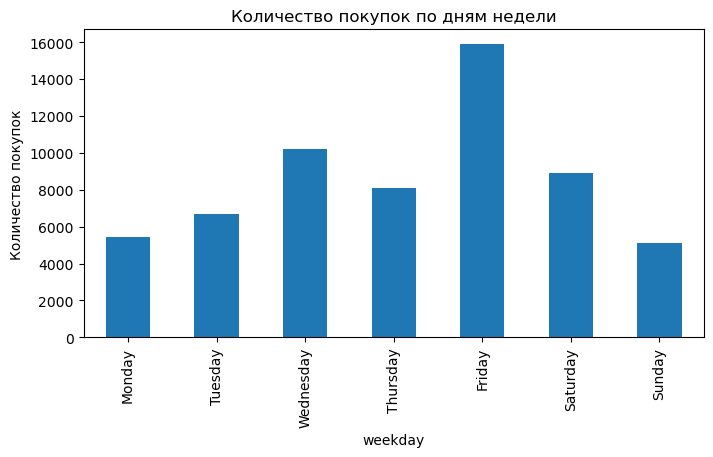

In [99]:
# день недели для покупок
purchases_clean['weekday'] = purchases_clean['date'].dt.day_name()

weekday_purchases = (
    purchases_clean
    .groupby('weekday')
    .size()
    .reindex([
        'Monday',
        'Tuesday',
        'Wednesday',
        'Thursday',
        'Friday',
        'Saturday',
        'Sunday'
    ])
)

weekday_purchases.plot(
    kind='bar',
    figsize=(8,4),
    title='Количество покупок по дням недели'
)

plt.ylabel('Количество покупок')
plt.show()

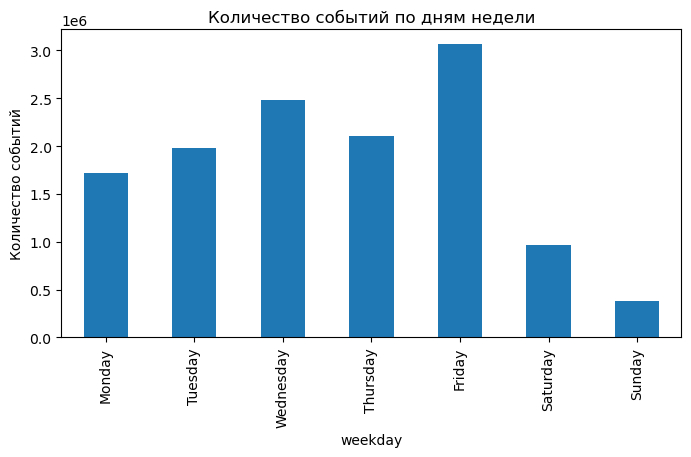

In [100]:
# день недели для событий
messages_clean['weekday'] = messages_clean['date'].dt.day_name()

weekday_messages = (
    messages_clean
    .groupby('weekday')
    .size()
    .reindex([
        'Monday',
        'Tuesday',
        'Wednesday',
        'Thursday',
        'Friday',
        'Saturday',
        'Sunday'
    ])
)

weekday_messages.plot(
    kind='bar',
    figsize=(8,4),
    title='Количество событий по дням недели'
)

plt.ylabel('Количество событий')
plt.show()

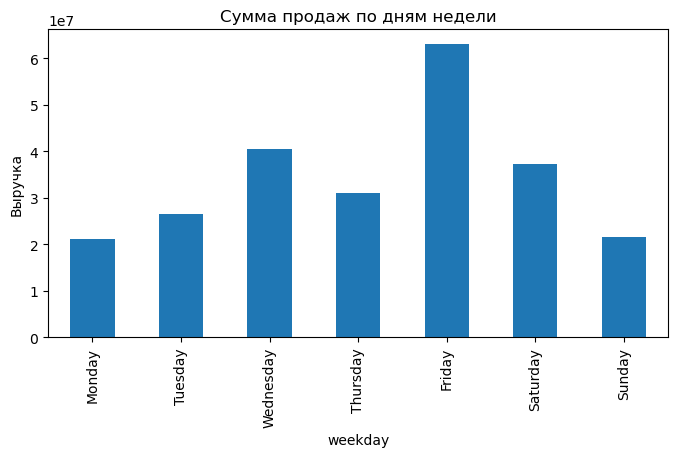

In [101]:
weekday_revenue = (
    purchases_clean
    .groupby('weekday')['price']
    .sum()
    .reindex([
        'Monday',
        'Tuesday',
        'Wednesday',
        'Thursday',
        'Friday',
        'Saturday',
        'Sunday'
    ])
)

weekday_revenue.plot(
    kind='bar',
    figsize=(8,4),
    title='Сумма продаж по дням недели'
)

plt.ylabel('Выручка')
plt.show()

<div style="
    background-color: #F2ECFF;
    border-left: 6px solid #B89CFF;
    padding: 15px 18px;
    border-radius: 8px;
    font-size: 15px;
    line-height: 1.6;
">

<b>Промежуточный вывод</b><br><br>

В ходе исследовательского анализа были изучены распределения основных признаков, структура маркетинговых событий и временные закономерности.
* Распределения quantity и price имеют выраженную правостороннюю асимметрию: большинство покупок содержат небольшое количество товаров и имеют относительно невысокую стоимость, при этом присутствуют единичные крупные заказы.
* Целевой признак сильно несбалансирован: только 1,93% клиентов совершают покупку в целевом периоде.
* В структуре событий преобладают отправки сообщений (send), далее следуют открытия (open), клики (click) и покупки (purchase), что соответствует классической маркетинговой воронке.
* Основным каналом коммуникации являются mobile push-уведомления (58,9%), на email приходится 41,1%сообщений.
* Анализ по месяцам показал отсутствие устойчивого роста покупок и наличие значительных колебаний активности. При этом количество маркетинговых событий со временем увеличивается, однако рост числа коммуникаций не сопровождается сопоставимым ростом покупок.
* Динамика выручки повторяет динамику количества покупок, тогда как средний чек остаётся относительно стабильным на протяжении всего периода наблюдений.
* По дням недели максимальная активность пользователей наблюдается в пятницу, а минимальная — в воскресенье и понедельник. Аналогичный паттерн характерен для количества маркетинговых событий и объёма выручки.
В целом данные выглядят качественными и содержат выраженные поведенческие и временные закономерности, которые могут быть полезны при построении признаков для модели прогнозирования покупок.

</div>

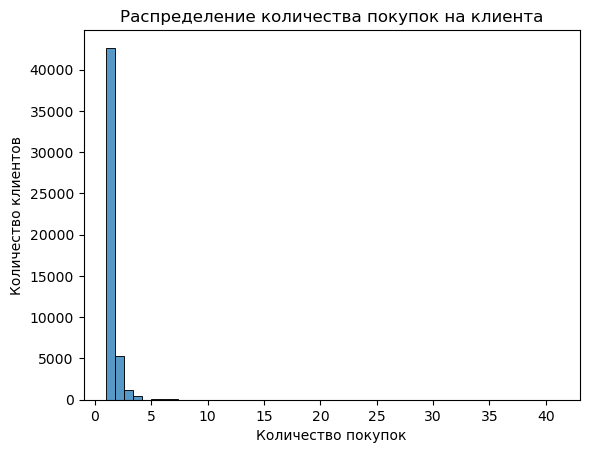

In [102]:
client_purchases = purchases_clean.groupby('client_id').size()
client_purchases.describe(percentiles=[0.5, 0.9, 0.95, 0.99])
sns.histplot(client_purchases, bins=50, kde=False)
plt.title('Распределение количества покупок на клиента')
plt.xlabel('Количество покупок')
plt.ylabel('Количество клиентов')
plt.show()

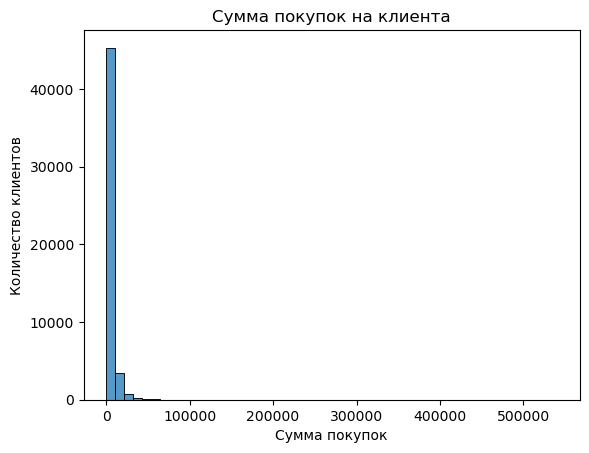

In [103]:
client_revenue = purchases_clean.groupby('client_id')['price'].sum()
client_revenue.describe(percentiles=[0.5, 0.9, 0.95, 0.99])
sns.histplot(client_revenue, bins=50, kde=False)
plt.title('Сумма покупок на клиента')
plt.xlabel('Сумма покупок')
plt.ylabel('Количество клиентов')
plt.show()

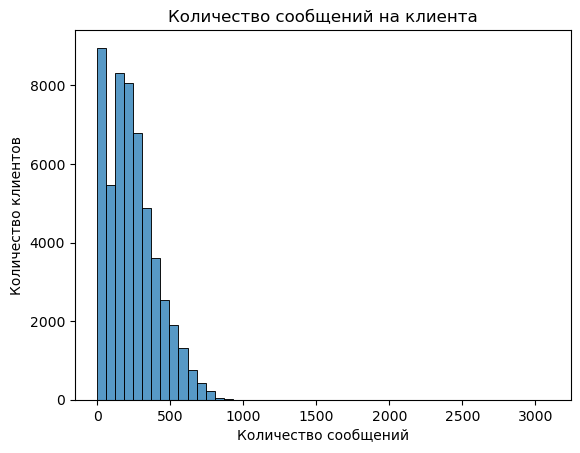

In [104]:
client_messages = messages_clean.groupby('client_id').size()
client_messages.describe(percentiles=[0.5, 0.9, 0.95, 0.99])
sns.histplot(client_messages, bins=50, kde=False)
plt.title('Количество сообщений на клиента')
plt.xlabel('Количество сообщений')
plt.ylabel('Количество клиентов')
plt.show()

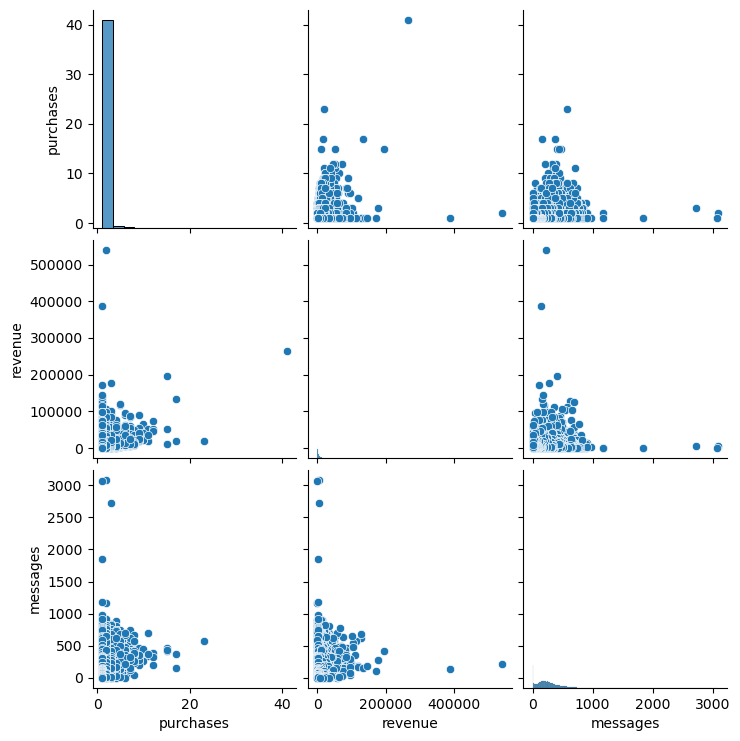

,purchases,revenue,messages
purchases,1.000000,0.365894,0.089410
revenue,0.365894,1.000000,0.016712
messages,0.089410,0.016712,1.000000


In [105]:
client_stats = pd.DataFrame({
    'purchases': purchases_clean.groupby('client_id').size(),
    'revenue': purchases_clean.groupby('client_id')['price'].sum(),
    'messages': messages_clean.groupby('client_id').size()
})

sns.pairplot(client_stats)
plt.show()

client_stats.corr()

<div style="
    background-color: #F2ECFF;
    border-left: 6px solid #B89CFF;
    padding: 15px 18px;
    border-radius: 8px;
    font-size: 15px;
    line-height: 1.6;
">

<b>Промежуточный вывод</b><br><br>

* Большинство клиентов совершают 1–2 покупки и получают относительно небольшое количество сообщений.
* Сумма покупок на клиента распределена с длинным хвостом - есть единичные «суперактивные» клиенты с большим количеством покупок и высоким чеком.
* Количество покупок и выручка умеренно коррелируют, а связь с количеством сообщений минимальна.
* Таким образом, простое увеличение числа коммуникаций не приводит к росту покупок на клиента.


</div>

In [106]:
print('Клиентов в target:',
      target['client_id'].nunique())

print('Клиентов в messages:',
      messages_clean['client_id'].nunique())

print('Клиентов в purchases:',
      purchases_clean['client_id'].nunique())

Клиентов в target: 49849
Клиентов в messages: 53329
Клиентов в purchases: 49849


In [107]:
# Уникальные клиенты в messages
all_clients_messages = messages_clean['client_id'].nunique()



In [108]:
# Доля клиентов по событиям
event_share_corrected = (
    messages_clean
    .groupby('event')['client_id']
    .nunique()
    / all_clients_messages * 100
)
display(event_share_corrected.round(2))



event
click          90.12
close           0.00
complain        0.53
hard_bounce    23.91
hbq_spam        1.51
open           83.84
purchase       78.86
send           99.95
soft_bounce     3.53
subscribe       0.14
unsubscribe     4.14
Name: client_id, dtype: float64

In [109]:
# Доля клиентов по каналам
channel_share_corrected = (
    messages_clean
    .groupby('channel')['client_id']
    .nunique()
    / all_clients_messages * 100
)
display(channel_share_corrected.round(2))

channel
email          73.29
mobile_push    69.26
Name: client_id, dtype: float64

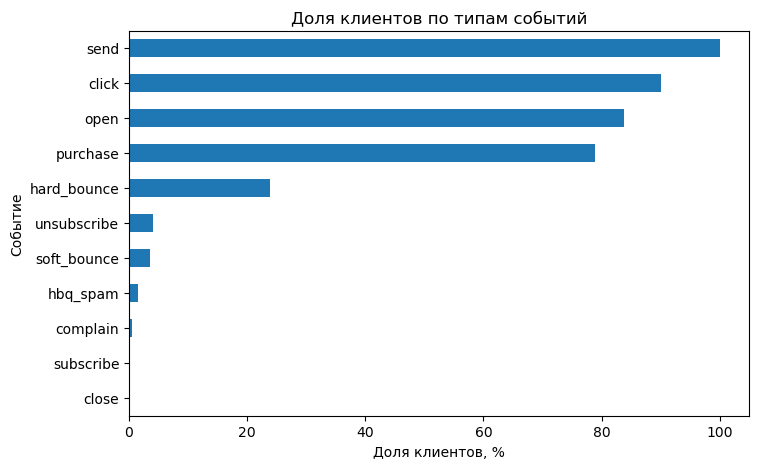

In [110]:
# Доли клиентов по событиям
event_share_corrected.sort_values().plot(
    kind='barh',
    figsize=(8, 5),
    title='Доля клиентов по типам событий'
)

plt.xlabel('Доля клиентов, %')
plt.ylabel('Событие')
plt.show()

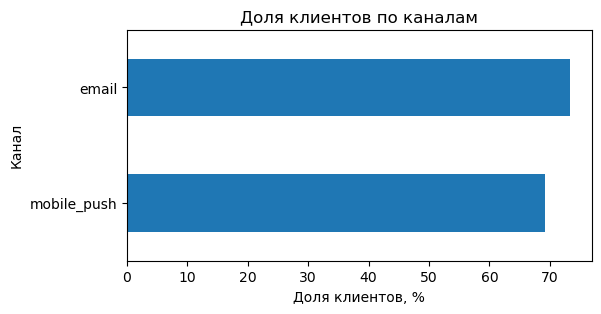

In [111]:
# Доли клиентов по каналам
channel_share_corrected.sort_values().plot(
    kind='barh',
    figsize=(6, 3),
    title='Доля клиентов по каналам'
)

plt.xlabel('Доля клиентов, %')
plt.ylabel('Канал')
plt.show()

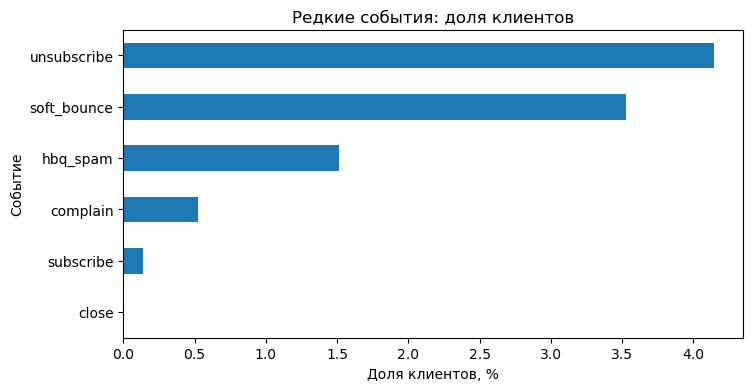

In [112]:
rare_events = event_share_corrected[event_share_corrected < 10]

rare_events.sort_values().plot(
    kind='barh',
    figsize=(8, 4),
    title='Редкие события: доля клиентов'
)

plt.xlabel('Доля клиентов, %')
plt.ylabel('Событие')
plt.show()

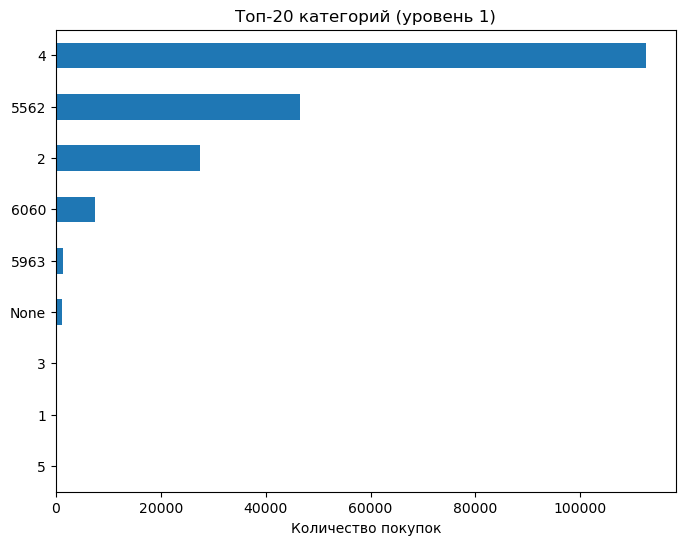

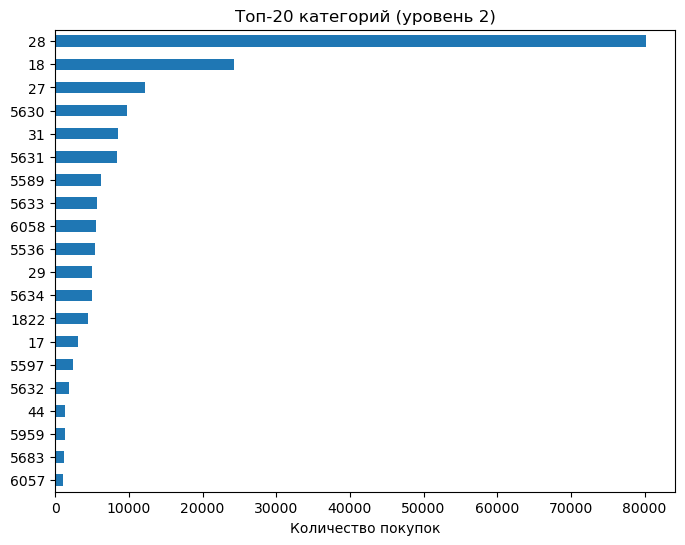

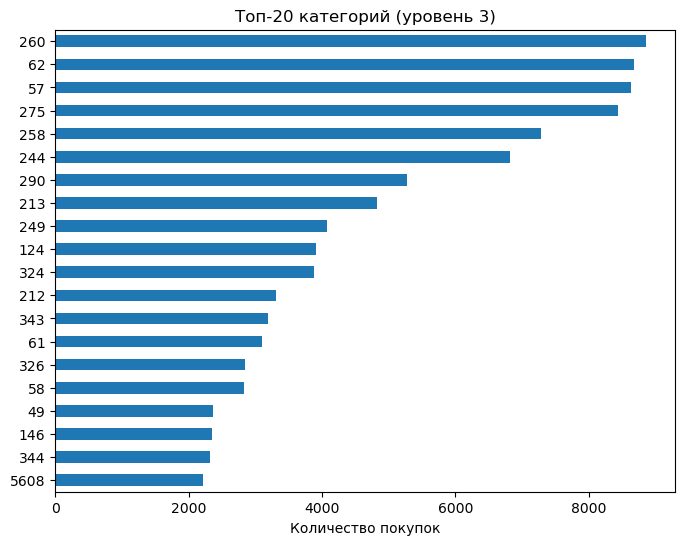

In [113]:
# Парсинг строковых списков в настоящие списки
parsed_category_lists = purchases_clean['category_ids'].apply(
    lambda x: [ast.literal_eval(item) for item in x]
)

# Функция для подсчета топовых категорий на выбранном уровне
def top_categories_by_level(category_lists, level=0, top_n=20):
    counter = Counter()
    for purchase in category_lists:
        for path in purchase:
            if len(path) > level:
                counter.update([path[level]])
    return pd.Series(counter).sort_values(ascending=False).head(top_n)

# Топ-20 категорий на уровне 1
top_level1 = top_categories_by_level(parsed_category_lists, level=0)
top_level1.plot(kind='barh', figsize=(8,6))
plt.title('Топ-20 категорий (уровень 1)')
plt.xlabel('Количество покупок')
plt.gca().invert_yaxis()
plt.show()

# Топ-20 категорий на уровне 2
top_level2 = top_categories_by_level(parsed_category_lists, level=1)
top_level2.plot(kind='barh', figsize=(8,6))
plt.title('Топ-20 категорий (уровень 2)')
plt.xlabel('Количество покупок')
plt.gca().invert_yaxis()
plt.show()

# Топ-20 категорий на уровне 3
top_level3 = top_categories_by_level(parsed_category_lists, level=2)
top_level3.plot(kind='barh', figsize=(8,6))
plt.title('Топ-20 категорий (уровень 3)')
plt.xlabel('Количество покупок')
plt.gca().invert_yaxis()
plt.show()


<div style="
    background-color: #F2ECFF;
    border-left: 6px solid #B89CFF;
    padding: 15px 18px;
    border-radius: 8px;
    font-size: 15px;
    line-height: 1.6;
">

<b>Промежуточный вывод</b><br><br>
* Столбец category_ids имеет вложенную структуру: одна покупка может содержать несколько товаров, а каждый товар относится к цепочке категорий разных уровней.
* Распределение категорий оказалось сильно неравномерным:
    * на первом уровне доминирует категория 4;
    * далее с заметным отрывом следуют категории 5562 и 2;
    * остальные категории встречаются значительно реже.
* Аналогичная концентрация сохраняется на более глубоких уровнях дерева категорий: небольшое число категорий формирует основную часть покупок.
* Это говорит о том, что ассортимент и продажи сосредоточены вокруг ограниченного набора товарных направлений.
Практический вывод для модели:
* категории потенциально могут стать полезными признаками;
* но использовать полное дерево категорий напрямую, вероятно, нецелесообразно из-за высокой размерности и дисбаланса.

</div>



In [114]:
client_features = pd.DataFrame({
    'messages_cnt': messages_clean.groupby('client_id').size(),
    'purchases_cnt': purchases_clean.groupby('client_id').size(),
    'revenue_sum': purchases_clean.groupby('client_id')['price'].sum()
}).reset_index()

client_features.columns = [
    'client_id',
    'messages_cnt',
    'purchases_cnt',
    'revenue_sum'
]

client_features = client_features.merge(
    target,
    on='client_id',
    how='left'
)

client_features.fillna(0, inplace=True)

client_features.head()

,client_id,messages_cnt,purchases_cnt,revenue_sum,target
0,1515915625468060902,177.0,1.0,6993.0,0.0
1,1515915625468061003,165.0,1.0,16235.0,1.0
2,1515915625468061099,276.0,1.0,299.0,0.0
3,1515915625468061100,428.0,1.0,2098.0,0.0
4,1515915625468061170,293.0,3.0,33601.0,0.0


In [115]:
display(
    client_features
    .groupby('target')[
        ['messages_cnt',
         'purchases_cnt',
         'revenue_sum']
    ]
    .agg([
        'mean',
        'median'
    ])
)

messages_cnt        purchases_cnt         revenue_sum        
               mean median          mean median         mean  median
target                                                              
0.0      206.175596  185.0      0.973537    1.0  3897.836042  2119.0
1.0      283.247659  266.0      1.738814    1.0  6773.110302  3698.0

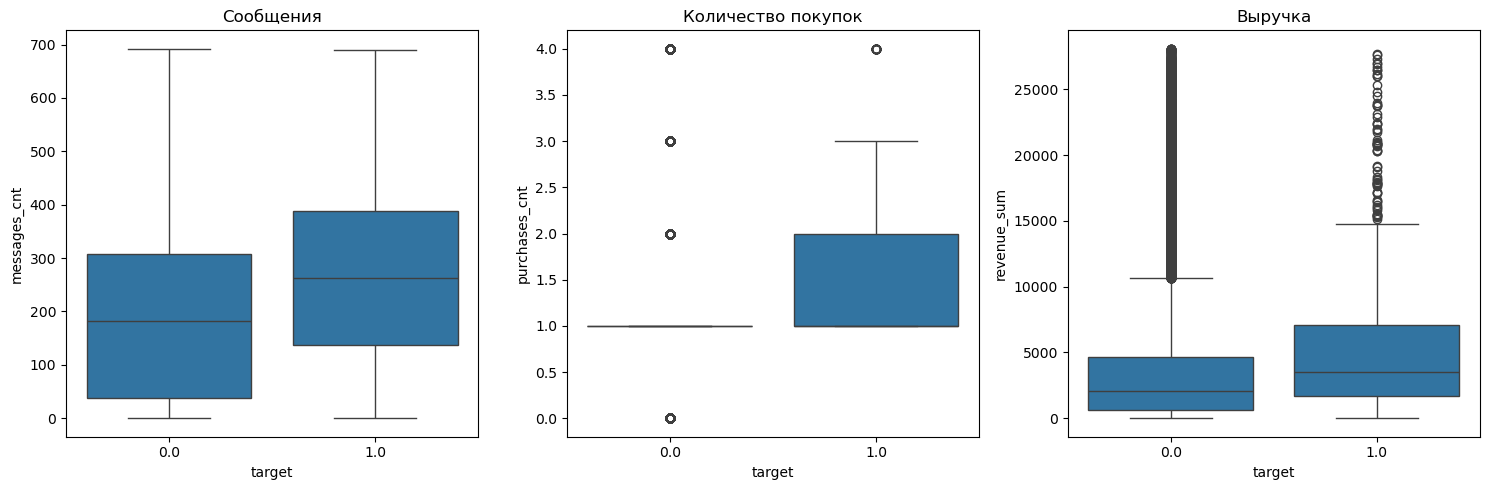

In [116]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(
    data=client_features[
        client_features['messages_cnt']
        <= client_features['messages_cnt'].quantile(0.99)
    ],
    x='target',
    y='messages_cnt',
    ax=axes[0]
)

sns.boxplot(
    data=client_features[
        client_features['purchases_cnt']
        <= client_features['purchases_cnt'].quantile(0.99)
    ],
    x='target',
    y='purchases_cnt',
    ax=axes[1]
)

sns.boxplot(
    data=client_features[
        client_features['revenue_sum']
        <= client_features['revenue_sum'].quantile(0.99)
    ],
    x='target',
    y='revenue_sum',
    ax=axes[2]
)

axes[0].set_title('Сообщения')
axes[1].set_title('Количество покупок')
axes[2].set_title('Выручка')

plt.tight_layout()
plt.show()

<div style="
    background-color: #F2ECFF;
    border-left: 6px solid #B89CFF;
    padding: 15px 18px;
    border-radius: 8px;
    font-size: 15px;
    line-height: 1.6;
">

<b>Промежуточный вывод</b><br><br>


Клиенты с target=1 в среднем получают больше сообщений:
* медиана: 266 против 185
* среднее: 283 против 206
- связь выглядит заметной.
У клиентов с target=1 выше покупательская активность:
* среднее число покупок: 1.74 против 0.97
* медиана одинаковая (=1), значит различие возникает за счёт части клиентов с повторными покупками.
У клиентов с target=1 выше денежная активность:
* медианная выручка: 3698 против 2119
* средняя: 6773 против 3898
По boxplot видно:
* распределения сильно скошены вправо (есть крупные клиенты);
* группы частично перекрываются - одного признака недостаточно;
* но направление различий устойчивое: target=1 связан с большей вовлечённостью и покупательной активностью.

</div>

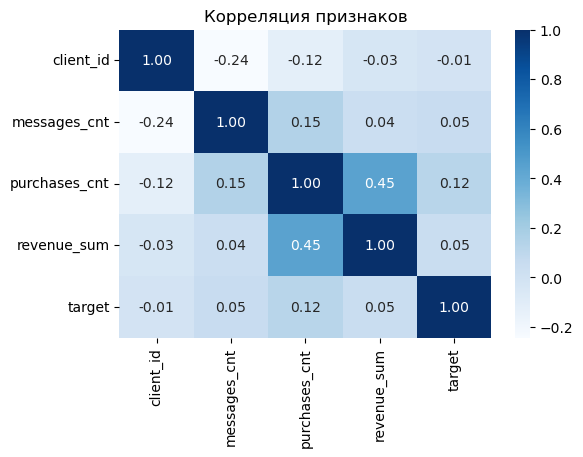

In [117]:
client_features.corr(numeric_only=True)

plt.figure(figsize=(6, 4))

sns.heatmap(
    client_features.corr(numeric_only=True),
    annot=True,
    cmap='Blues',
    fmt='.2f'
)

plt.title('Корреляция признаков')
plt.show()

<div style="
    background-color: #F2ECFF;
    border-left: 6px solid #B89CFF;
    padding: 15px 18px;
    border-radius: 8px;
    font-size: 15px;
    line-height: 1.6;
">

<b>Промежуточный вывод</b><br><br>

* Связь признаков с целевой переменной (target) есть, но слабая по линейной корреляции:
    * purchases_cnt <-> target = 0.12
    * messages_cnt <-> target = 0.05
    * revenue_sum <-> target = 0.05
* Самая заметная связь внутри признаков:
    * purchases_cnt <-> revenue_sum = 0.45
- то есть, чем больше покупок, тем выше суммарная выручка. Но корреляция умеренная, значит признаки не дублируют друг друга полностью.
* messages_cnt почти не связан напрямую с покупками и выручкой:
    * messages_cnt <-> purchases_cnt = 0.15
    * messages_cnt <-> revenue_sum = 0.04
- количество сообщений само по себе не гарантирует покупки.
* client_id ожидаемо не несёт информации и позже должен быть исключён из признаков.

</div>

<div style="
    background-color: #F2ECFF;
    border-left: 6px solid #B89CFF;
    padding: 15px 18px;
    border-radius: 8px;
    font-size: 15px;
    line-height: 1.6;
">

<b>Общий вывод</b><br><br>

1. Общая статистика по клиентам и покупкам
* Всего клиентов в target: 49 849
* Всего клиентов в messages: 53 329
* Всего клиентов в purchases: 49 849
* Среднее количество сообщений на клиента: 206 для класса 0, 283 для класса 1
* Среднее количество покупок на клиента: 0.97 для класса 0, 1.74 для класса 1
* Средняя выручка на клиента: 3 898 для класса 0, 6 773 для класса 1
Вывод: активные клиенты (target = 1) совершают больше сообщений, покупок и приносят больше выручки.

2. Временная динамика
* Суммарная выручка и средний чек показывают выраженные сезонные колебания по месяцам.
* Пик активности наблюдается в июле, октябре и декабре.
* Наибольшее количество покупок приходится на пятницу.

3. Категории товаров
* В среднем на покупку приходится ~3.3 категорий, медиана = 2
* Большинство покупок сосредоточено в небольшом наборе популярных категорий
* На первом уровне категорий (уровень 1) доминируют категории 4, 5562, 2
* Данные готовы для дальнейшей работы с категориальными признаками (one-hot, count encoding, embedding и т.д.)

4. Сообщения и каналы
* Почти все клиенты получают хотя бы одно сообщение (send ≈ 107%), открывают и кликают примерно 80–90%
* Редкие события (unsubscribe, soft_bounce, hbq_spam) встречаются у меньшинства клиентов (<5%)
* Наиболее популярные каналы: email и mobile_push

5. Корреляции
* Линейная корреляция с целевой переменной слабая:
    * purchases_cnt <-> target ≈ 0.12
    * messages_cnt <-> target ≈ 0.05
    * revenue_sum <-> target ≈ 0.05
* Наибольшая внутренняя корреляция: purchases_cnt <-> revenue_sum ≈ 0.45
Вывод: линейные зависимости слабые, но визуальные различия между классами на графиках заметны, что подтверждает необходимость дальнейшего Feature Engineering.


</div>

<h1>Подготовка данных и разработка признаков для этапа МО</h1>

In [118]:
# Средний чек
client_features['avg_check'] = (
    client_features['revenue_sum'] /
    client_features['purchases_cnt']
)

# Конверсия сообщений в покупки
client_features['purchase_conversion'] = (
    client_features['purchases_cnt'] /
    client_features['messages_cnt']
)

# Флаг наличия покупки
client_features['has_purchase'] = (
    client_features['purchases_cnt'] > 0
).astype(int)

# Логарифмы
client_features['log_messages'] = np.log1p(
    client_features['messages_cnt']
)

client_features['log_revenue'] = np.log1p(
    client_features['revenue_sum']
)

# обработка деления на 0
client_features.replace(
    [np.inf, -np.inf],
    np.nan,
    inplace=True
)

# пока заполним нулями
client_features.fillna(0, inplace=True)

# проверка
display(client_features.head())

display(
    client_features[
        [
            'avg_check',
            'purchase_conversion',
            'has_purchase',
            'log_messages',
            'log_revenue'
        ]
    ].describe()
)

print('Пропуски:')
display(client_features.isna().sum())

,client_id,messages_cnt,purchases_cnt,revenue_sum,target,avg_check,purchase_conversion,has_purchase,log_messages,log_revenue
0,1515915625468060902,177.0,1.0,6993.0,0.0,6993.000000,0.005650,1,5.181784,8.852808
1,1515915625468061003,165.0,1.0,16235.0,1.0,16235.000000,0.006061,1,5.111988,9.694986
2,1515915625468061099,276.0,1.0,299.0,0.0,299.000000,0.003623,1,5.624018,5.703782
3,1515915625468061100,428.0,1.0,2098.0,0.0,2098.000000,0.002336,1,6.061457,7.649216
4,1515915625468061170,293.0,3.0,33601.0,0.0,11200.333333,0.010239,1,5.683580,10.422341


,avg_check,purchase_conversion,has_purchase,log_messages,log_revenue
count,61196.000000,61196.000000,61196.000000,61196.000000,61196.000000
mean,3272.412424,0.007777,0.814579,4.362223,6.487798
std,5219.072827,0.039380,0.388642,2.053428,3.235980
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,679.000000,0.000000,1.000000,3.761200,6.551080
50%,1999.000000,0.003279,1.000000,5.231109,7.694848
75%,4077.250000,0.006289,1.000000,5.752573,8.496378
max,387583.000000,4.000000,1.000000,8.035603,13.200082


Пропуски:


client_id              0
messages_cnt           0
purchases_cnt          0
revenue_sum            0
target                 0
avg_check              0
purchase_conversion    0
has_purchase           0
log_messages           0
log_revenue            0
dtype: int64

In [119]:
# Преобразуем строки с category_ids в списки Python 
purchases_clean['category_ids'] = purchases_clean['category_ids'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

# Функция для добавления бинарных признаков для топ-N категорий уровня lvl
def add_category_features_fixed(df, client_features, level=0, top_n=20):
    from collections import Counter
   
    cats_level = df['category_ids'].dropna().apply(lambda x: x[level] if len(x)>level else None)
    top_cats = [cat for cat,_ in Counter(cats_level).most_common(top_n)]
    
    for cat in top_cats:
        col_name = f'category_lvl{level+1}_{cat}'
        client_features[col_name] = df.groupby('client_id')['category_ids'].apply(
            lambda ids: int(any(len(c)>level and c[level]==cat for c in ids))
        ).reindex(client_features['client_id'], fill_value=0)

# Добавляем признаки для всех трех уровней
for lvl in range(3):
    add_category_features_fixed(purchases_clean, client_features, level=lvl, top_n=20)

# Проверка
client_features.filter(like='category_lvl').head()

,"category_lvl1_['4', '28', '57', '431']","category_lvl1_['4', '28', '244', '432']","category_lvl1_['4', '28', '260', '420']","category_lvl1_['2', '18', '258', '441']","category_lvl1_['4', '28', '275', '421']",category_lvl1_[],"category_lvl1_['4', '28', '124', '415']","category_lvl1_['4', '28', '62', '657']","category_lvl1_['4', '28', '62', '656']","category_lvl1_['4', '28', '275', '673']",...,"category_lvl3_['4', '28', '62', '656']","category_lvl3_['4', '28', '343', '425']","category_lvl3_['4', '28', '213', '436']","category_lvl3_['4', '28', '290', '422']","category_lvl3_['4', '31', '326', '505']","category_lvl3_['2', '18', '344', '445']","category_lvl3_['4', '28', '249', '616']","category_lvl3_['4', '28', '146', '548']","category_lvl3_['5562', '5631', '5608', '561']","category_lvl3_['4', '28', '58', '434']"
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [120]:
# Убираем старые колонки
category_cols = [col for col in client_features.columns if col.startswith('category_lvl')]
client_features = client_features.drop(columns=category_cols, errors='ignore')

# Преобразуем строки в списки
def parse_str_list(x):
    try:
        return ast.literal_eval(x)
    except:
        return []

purchases_clean['category_ids_parsed'] = purchases_clean['category_ids'].apply(
    lambda lst: [parse_str_list(s) for s in lst] if isinstance(lst, list) else []
)


category_rows = []
for client_id, cat_paths in purchases_clean[['client_id','category_ids_parsed']].itertuples(index=False):
    for path in cat_paths:
        category_rows.append({
            'client_id': client_id,
            'category_lvl1': path[0] if len(path) > 0 else 'unknown',
            'category_lvl2': path[1] if len(path) > 1 else 'unknown',
            'category_lvl3': path[2] if len(path) > 2 else 'unknown'
        })

categories_long = pd.DataFrame(category_rows)

# Создание бинарных признаков для топ-20 категорий на каждом уровне
for level_col in ['category_lvl1','category_lvl2','category_lvl3']:
    top_categories = categories_long[level_col].value_counts().head(20).index
    for cat in top_categories:
        feature_name = f'{level_col}_{cat}'
        clients_with_cat = categories_long.loc[categories_long[level_col]==cat,'client_id'].drop_duplicates()
        client_features[feature_name] = client_features['client_id'].isin(clients_with_cat).astype(int)

# Проверка
category_cols = [col for col in client_features.columns if col.startswith('category_lvl')]
print('Количество category-признаков:', len(category_cols))
print('NaN в category-признаках:', client_features[category_cols].isna().sum().sum())
display(client_features[category_cols].head())

Количество category-признаков: 49
NaN в category-признаках: 0


,category_lvl1_4,category_lvl1_5562,category_lvl1_2,category_lvl1_6060,category_lvl1_unknown,category_lvl1_5963,category_lvl1_3,category_lvl1_1,category_lvl1_5,category_lvl2_28,...,category_lvl3_124,category_lvl3_324,category_lvl3_212,category_lvl3_343,category_lvl3_61,category_lvl3_326,category_lvl3_58,category_lvl3_49,category_lvl3_146,category_lvl3_344
0,1,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,0,1,0,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [121]:
# Каналы сообщений

channel_features = pd.crosstab(
    messages_clean['client_id'],
    messages_clean['channel']
)

channel_features = (channel_features > 0).astype(int)

channel_features.columns = [
    f'channel_{col}' for col in channel_features.columns
]

client_features = client_features.merge(
    channel_features,
    on='client_id',
    how='left'
)

channel_cols = [col for col in client_features.columns if col.startswith('channel_')]
client_features[channel_cols] = client_features[channel_cols].fillna(0).astype(int)

print('Количество channel-признаков:', len(channel_cols))
print('NaN в channel-признаках:', client_features[channel_cols].isna().sum().sum())

display(client_features[channel_cols].head())
display(client_features[channel_cols].sum().sort_values(ascending=False))

Количество channel-признаков: 2
NaN в channel-признаках: 0


,channel_email,channel_mobile_push
0,1,0
1,1,0
2,1,1
3,0,1
4,1,1


channel_email          39087
channel_mobile_push    36936
dtype: int64

In [122]:
# События сообщений: бинарные признаки по типам event

event_features = pd.crosstab(
    messages_clean['client_id'],
    messages_clean['event']
)

event_features = (event_features > 0).astype(int)

event_features.columns = [
    f'event_{col}' for col in event_features.columns
]

client_features = client_features.merge(
    event_features,
    on='client_id',
    how='left'
)

event_cols = [col for col in client_features.columns if col.startswith('event_')]
client_features[event_cols] = client_features[event_cols].fillna(0).astype(int)

print('Количество event-признаков:', len(event_cols))
print('NaN в event-признаках:', client_features[event_cols].isna().sum().sum())

display(client_features[event_cols].head())
display(client_features[event_cols].sum().sort_values(ascending=False))

Количество event-признаков: 11
NaN в event-признаках: 0


,event_click,event_close,event_complain,event_hard_bounce,event_hbq_spam,event_open,event_purchase,event_send,event_soft_bounce,event_subscribe,event_unsubscribe
0,1,0,0,0,0,1,1,1,0,0,1
1,1,0,0,0,0,1,1,1,0,0,0
2,1,0,0,1,0,1,0,1,0,0,0
3,1,0,0,1,0,1,1,1,1,0,0
4,1,0,0,0,0,1,1,1,0,0,0


event_send           53303
event_click          48060
event_open           44710
event_purchase       42055
event_hard_bounce    12752
event_unsubscribe     2209
event_soft_bounce     1882
event_hbq_spam         806
event_complain         281
event_subscribe         75
event_close              1
dtype: int64

In [123]:
# Количество уникальных дней с сообщениями 
messages_clean['date'] = pd.to_datetime(messages_clean['date'])
days_active_msg = messages_clean.groupby('client_id')['date'].nunique().reset_index()
days_active_msg.rename(columns={'date':'days_active_messages'}, inplace=True)

# Количество уникальных дней с покупками
purchases_clean['date'] = pd.to_datetime(purchases_clean['date'])
days_active_pur = purchases_clean.groupby('client_id')['date'].nunique().reset_index()
days_active_pur.rename(columns={'date':'days_active_purchases'}, inplace=True)

# Последняя дата сообщений и покупок для вычисления дней с последнего события
last_msg_date = messages_clean.groupby('client_id')['date'].max().reset_index()
last_msg_date.rename(columns={'date':'last_msg_date'}, inplace=True)

last_purchase_date = purchases_clean.groupby('client_id')['date'].max().reset_index()
last_purchase_date.rename(columns={'date':'last_purchase_date'}, inplace=True)

# Конечная дата периода  
end_date = max(messages_clean['date'].max(), purchases_clean['date'].max())

# Вычисляем дни с последнего события
last_msg_date['days_since_last_message'] = (end_date - last_msg_date['last_msg_date']).dt.days
last_purchase_date['days_since_last_purchase'] = (end_date - last_purchase_date['last_purchase_date']).dt.days

# Доля сообщений, которые привели к покупке
msg_purchase = messages_clean.groupby('client_id')['event'].apply(lambda x: (x=='purchase').sum()).reset_index()
msg_total = messages_clean.groupby('client_id')['event'].count().reset_index()
event_purchase_ratio = msg_total.merge(msg_purchase, on='client_id', how='left', suffixes=('_total','_purchase'))
event_purchase_ratio['event_purchase_ratio'] = event_purchase_ratio['event_purchase'] / event_purchase_ratio['event_total']

# Объединение всех признаков с client_features 
client_features = client_features.merge(days_active_msg, on='client_id', how='left')
client_features = client_features.merge(days_active_pur, on='client_id', how='left')
client_features = client_features.merge(last_msg_date[['client_id','days_since_last_message']], on='client_id', how='left')
client_features = client_features.merge(last_purchase_date[['client_id','days_since_last_purchase']], on='client_id', how='left')
client_features = client_features.merge(event_purchase_ratio[['client_id','event_purchase_ratio']], on='client_id', how='left')

# Заполняем пропуски нулями
client_features[['days_active_messages','days_active_purchases','days_since_last_message',
                 'days_since_last_purchase','event_purchase_ratio']] = client_features[
    ['days_active_messages','days_active_purchases','days_since_last_message',
     'days_since_last_purchase','event_purchase_ratio']
].fillna(0)

# Проверка
client_features[['days_active_messages','days_active_purchases','days_since_last_message',
                 'days_since_last_purchase','event_purchase_ratio']].describe()

,days_active_messages,days_active_purchases,days_since_last_message,days_since_last_purchase,event_purchase_ratio
count,61196.000000,61196.000000,61196.000000,61196.000000,61196.000000
mean,132.354108,0.983855,57.523351,294.822015,0.024073
std,98.791643,0.762467,144.325408,218.530506,0.069148
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28.000000,1.000000,1.000000,56.000000,0.000000
50%,139.000000,1.000000,1.000000,288.000000,0.003680
75%,212.000000,1.000000,3.000000,469.000000,0.008197
max,506.000000,41.000000,638.000000,641.000000,0.769231


<div style="
    background-color: #F2ECFF;
    border-left: 6px solid #B89CFF;
    padding: 15px 18px;
    border-radius: 8px;
    font-size: 15px;
    line-height: 1.6;
">

<b>Промежуточный вывод</b><br><br>

На этапе разработки признаков была сформирована итоговая клиентская витрина client_features, объединяющая информацию о рассылках, покупках и целевом признаке (target) по client_id.
1. Базовые клиентские агрегаты
Для каждого клиента были рассчитаны основные количественные характеристики:
* messages_cnt — количество взаимодействий с сообщениями;
* purchases_cnt — количество покупок;
* revenue_sum — суммарная выручка по клиенту.
2. Производные числовые признаки
Для расширения описания поведения клиента были созданы дополнительные признаки:
* avg_check — средний чек (revenue_sum / purchases_cnt);
* purchase_conversion — отношение числа покупок к числу сообщений;
* has_purchase — бинарный признак наличия хотя бы одной покупки;
* log_messages — логарифм количества сообщений (log1p);
* log_revenue — логарифм суммарной выручки (log1p).
При расчёте производных признаков были обработаны потенциальные ошибки деления на ноль и заполнены пропуски.
3. Категориальные признаки
На основе истории покупок были построены признаки категорий товаров:
* выделены уровни вложенности категорий (category_lvl1, category_lvl2, category_lvl3);
* для наиболее популярных категорий построены бинарные признаки присутствия категории у клиента.
Дополнительно на основе истории рассылок были добавлены:
* признаки каналов коммуникации (channel);
* признаки событий взаимодействия (event).
4. Контроль качества признаков
После объединения и преобразования данных:
* отсутствуют пропущенные значения в итоговой витрине;
* все категориальные признаки представлены в бинарном формате (0/1);
* числовые признаки подготовлены для последующего обучения моделей.
Итогом этапа стала единая таблица признаков client_features, готовая для разделения данных и построения baseline-моделей.

</div>

In [124]:
X = client_features.drop(columns=['client_id', 'target'])

y = client_features['target']

# 70/15/15 split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print('Train shape:', X_train.shape)
print('Validation shape:', X_valid.shape)
print('Test shape:', X_test.shape)

# Проверка баланса классов
print('Train target distribution:\n', y_train.value_counts(normalize=True))
print('Validation target distribution:\n', y_valid.value_counts(normalize=True))
print('Test target distribution:\n', y_test.value_counts(normalize=True))

Train shape: (42837, 75)
Validation shape: (9179, 75)
Test shape: (9180, 75)
Train target distribution:
 target
0.0    0.984289
1.0    0.015711
Name: proportion, dtype: float64
Validation target distribution:
 target
0.0    0.984312
1.0    0.015688
Name: proportion, dtype: float64
Test target distribution:
 target
0.0    0.984314
1.0    0.015686
Name: proportion, dtype: float64


In [125]:
# Логрег
logreg = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',  
    random_state=42
)
logreg.fit(X_train, y_train)

y_valid_pred_proba = logreg.predict_proba(X_valid)[:,1]
y_valid_pred = logreg.predict(X_valid)

print("Logistic Regression:")
print("ROC-AUC:", round(roc_auc_score(y_valid, y_valid_pred_proba), 4))
print("F1-score:", round(f1_score(y_valid, y_valid_pred), 4))



Logistic Regression:
ROC-AUC: 0.7515
F1-score: 0.0564


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [126]:
# RF
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_valid_pred_proba_rf = rf.predict_proba(X_valid)[:,1]
y_valid_pred_rf = rf.predict(X_valid)

print("\nRandom Forest:")
print("ROC-AUC:", round(roc_auc_score(y_valid, y_valid_pred_proba_rf), 4))
print("F1-score:", round(f1_score(y_valid, y_valid_pred_rf), 4))




Random Forest:
ROC-AUC: 0.7315
F1-score: 0.0817


,feature,importance
73,days_since_last_purchase,0.133029
3,avg_check,0.078460
2,revenue_sum,0.075919
7,log_revenue,0.071182
71,days_active_purchases,0.069733
1,purchases_cnt,0.068505
4,purchase_conversion,0.057581
6,log_messages,0.052948
0,messages_cnt,0.052704
72,days_since_last_message,0.046989


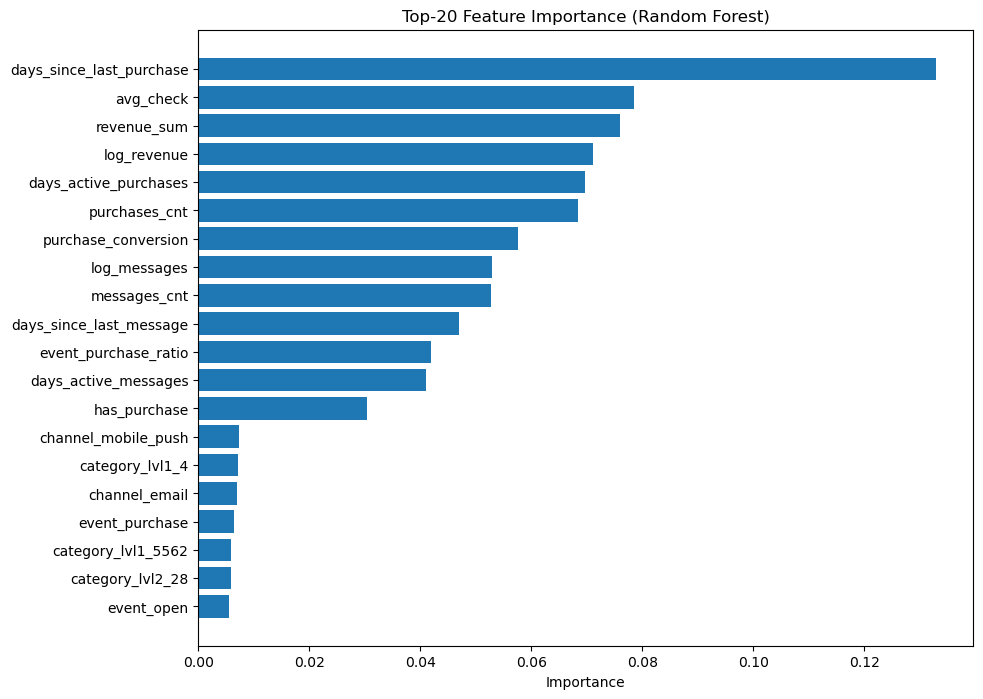

In [127]:
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf.feature_importances_
})


feature_importance = (
    feature_importance
    .sort_values('importance', ascending=False)
)


display(feature_importance.head(20))


plt.figure(figsize=(10,8))

plt.barh(
    feature_importance.head(20)['feature'][::-1],
    feature_importance.head(20)['importance'][::-1]
)

plt.title('Top-20 Feature Importance (Random Forest)')
plt.xlabel('Importance')

plt.show()

In [128]:
feature_importance['cum_importance'] = (
    feature_importance['importance']
    .cumsum()
)

display(
    feature_importance[
        ['feature', 'importance', 'cum_importance']
    ].head(20)
)

,feature,importance,cum_importance
73,days_since_last_purchase,0.133029,0.133029
3,avg_check,0.078460,0.211489
2,revenue_sum,0.075919,0.287407
7,log_revenue,0.071182,0.358589
71,days_active_purchases,0.069733,0.428322
1,purchases_cnt,0.068505,0.496827
4,purchase_conversion,0.057581,0.554408
6,log_messages,0.052948,0.607356
0,messages_cnt,0.052704,0.660061
72,days_since_last_message,0.046989,0.707049


<div style="
    background-color: #F2ECFF;
    border-left: 6px solid #B89CFF;
    padding: 15px 18px;
    border-radius: 8px;
    font-size: 15px;
    line-height: 1.6;
">

<b>Промежуточный вывод</b><br><br>

После завершения подготовки признаков данные были разделены на обучающую, валидационную и тестовую выборки в пропорции 70 / 15 / 15 с использованием стратификации по целевому признаку. Это позволило сохранить исходный дисбаланс классов во всех выборках.

Размер выборок:
* Train: 42837 объектов
* Validation: 9179 объектов
* Test: 9180 объектов
Доля положительного класса (target=1) составила около 1.57% во всех частях данных, что подтверждает наличие выраженного дисбаланса классов.

Обучение baseline-моделей
Для первичной оценки качества были обучены две модели классификации:
Модель	ROC-AUC	F1-score
Logistic Regression	0.7515	0.0564
Random Forest	0.7315	0.0817

Для компенсации дисбаланса классов использовался параметр class_weight='balanced'.


* Логистическая регрессия показала лучший результат по ROC-AUC (0.7515), что означает более качественное ранжирование клиентов по вероятности покупки.
* Случайный лес показал более высокий F1-score (0.0817), однако уступил по ROC-AUC.
* Так как основной целевой метрикой проекта является ROC-AUC, на текущем этапе предпочтительной baseline-моделью можно считать логистическую регрессию.

Анализ важности признаков (Random Forest)
Для интерпретации модели был проведён анализ feature importance.
Наибольший вклад внесли признаки:
1. days_since_last_purchase
2. avg_check
3. revenue_sum
4. log_revenue
5. days_active_purchases
6. purchases_cnt
7. purchase_conversion
8. messages_cnt
9. days_since_last_message
10. event_purchase_ratio

Основной вклад в качество модели внесли:
* признаки покупательской активности;
* денежные показатели клиента;
* показатели вовлечённости в коммуникации.

Категориальные признаки (категории товаров, каналы коммуникации, отдельные события) внесли существенно меньший вклад.
Таким образом, построенный baseline подтвердил, что история покупок и интенсивность взаимодействия с коммуникациями являются наиболее значимыми факторами для прогнозирования вероятности покупки в течение следующих 90 дней.

</div>


In [129]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        random_state=42,
        class_weight='balanced',
        max_iter=5000
    ))
])

param_grid = {
    'model__C': [0.01, 0.1, 1, 5, 10],
    'model__penalty': ['l2']
}

grid_lr = GridSearchCV(
    pipe,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_lr.fit(X_train, y_train)

print("Best params:")
print(grid_lr.best_params_)

print("\nBest CV ROC-AUC:")
print(round(grid_lr.best_score_, 4))

best_lr = grid_lr.best_estimator_

y_valid_proba = best_lr.predict_proba(X_valid)[:, 1]

print("\nValidation ROC-AUC:")
print(round(
    roc_auc_score(y_valid, y_valid_proba),
    4
))

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best params:
{'model__C': 0.01, 'model__penalty': 'l2'}

Best CV ROC-AUC:
0.7676

Validation ROC-AUC:
0.7602


In [130]:
selected_features = feature_importance[
    feature_importance['cum_importance'] <= 0.80
]['feature'].tolist()

print('Количество признаков:', len(selected_features))
print(selected_features)

# новые выборки
X_train_sel = X_train[selected_features]
X_valid_sel = X_valid[selected_features]

# переобучение лучшей логрег модели
best_lr.fit(X_train_sel, y_train)

y_valid_sel = best_lr.predict_proba(
    X_valid_sel
)[:,1]

from sklearn.metrics import roc_auc_score

print(
    'Validation ROC-AUC:',
    round(
        roc_auc_score(
            y_valid,
            y_valid_sel
        ),
        4
    )
)

Количество признаков: 12
['days_since_last_purchase', 'avg_check', 'revenue_sum', 'log_revenue', 'days_active_purchases', 'purchases_cnt', 'purchase_conversion', 'log_messages', 'messages_cnt', 'days_since_last_message', 'event_purchase_ratio', 'days_active_messages']
Validation ROC-AUC: 0.7606


In [131]:
# финальная модель на сокращённых признаках

X_test_sel = X_test[selected_features]

y_test_proba = best_lr.predict_proba(
    X_test_sel
)[:, 1]

y_test_pred = best_lr.predict(
    X_test_sel
)

from sklearn.metrics import roc_auc_score, f1_score

print(
    'TEST ROC-AUC:',
    round(
        roc_auc_score(
            y_test,
            y_test_proba
        ),
        4
    )
)

print(
    'TEST F1:',
    round(
        f1_score(
            y_test,
            y_test_pred
        ),
        4
    )
)

TEST ROC-AUC: 0.775
TEST F1: 0.0676


<div style="
    background-color: #F2ECFF;
    border-left: 6px solid #B89CFF;
    padding: 15px 18px;
    border-radius: 8px;
    font-size: 15px;
    line-height: 1.6;
">

<b>Итоговый вывод: оптимизация модели и тестирование</b><br><br>


После построения baseline-моделей была проведена оптимизация качества классификации.

В качестве базовых алгоритмов были рассмотрены:
* Logistic Regression;
* Random Forest.

Первоначальные результаты показали:
Модель	ROC-AUC	F1-score
Logistic Regression	0.7515	0.0564
Random Forest	0.7315	0.0817

Поскольку целевой метрикой проекта являлась ROC-AUC, дальнейшая оптимизация проводилась для логистической регрессии.

Для улучшения качества были выполнены следующие действия:
* масштабирование признаков (StandardScaler);
* подбор гиперпараметров (GridSearchCV);
* настройка коэффициента регуляризации;
* отбор наиболее информативных признаков на основе feature importance.

В результате оптимизации:
* лучшим параметром регуляризации стало значение C = 0.01;
* ROC-AUC на валидационной выборке увеличился до 0.7602;
* после отбора признаков (80% накопленной важности) итоговая метрика составила 0.7606.

Количество признаков удалось сократить:
* исходный набор — 75 признаков;
* итоговый набор — 12 признаков.

Наиболее значимыми признаками оказались:
* время с последней покупки;
* средний чек;
* суммарная выручка;
* количество покупок;
* конверсия сообщений в покупки;
* активность клиента.

Финальная оценка модели была проведена на тестовой выборке.

Итоговые метрики:
* ROC-AUC = 0.7750
* F1-score = 0.0676

Полученные результаты показывают, что разработанная модель способна достаточно хорошо разделять клиентов по вероятности совершения покупки в течение следующих 90 дней и может использоваться как базовое решение для задач маркетингового прогнозирования.



</div>

**Общий вывод по проекту**


В рамках проекта была решена задача бинарной классификации: необходимо было предсказать вероятность того, что клиент совершит покупку в течение следующих 90 дней.

На первом этапе были загружены и изучены данные о покупках, рекламных рассылках и целевом признаке. В ходе предобработки были проверены типы данных, пропуски, дубликаты и корректность форматов дат. Полные дубликаты были удалены, а даты приведены к формату datetime.

На этапе исследовательского анализа данных было выявлено, что целевой признак сильно несбалансирован: доля клиентов, совершивших покупку в целевом периоде, составляет около 1.6%. Также было установлено, что клиенты с target=1 в среднем активнее взаимодействуют с рассылками и имеют более высокие показатели покупательской активности.

На этапе разработки признаков была создана клиентская витрина client_features, в которой данные были агрегированы на уровне client_id. Были добавлены базовые числовые признаки, производные признаки покупательской активности, логарифмированные признаки, бинарные признаки категорий товаров, каналов коммуникации и событий взаимодействия с сообщениями.

После подготовки признаков данные были разделены на обучающую, валидационную и тестовую выборки в пропорции 70/15/15 с сохранением баланса классов.

В качестве baseline-моделей были обучены Logistic Regression и Random Forest. Лучшее качество по основной метрике ROC-AUC показала логистическая регрессия.

Для улучшения модели были применены масштабирование признаков, подбор гиперпараметров с помощью GridSearchCV и отбор наиболее информативных признаков. 

В результате итоговая модель использовала 12 признаков вместо исходных 75, при этом качество не ухудшилось, а немного выросло.

Финальная модель была протестирована на отложенной тестовой выборке. Итоговые метрики составили:
* ROC-AUC: 0.7750
* F1-score: 0.0676
  
Таким образом, в ходе проекта удалось построить модель, которая ранжирует клиентов по вероятности покупки лучше случайного классификатора и может использоваться как базовое решение для приоритизации клиентов в маркетинговых коммуникациях. Наиболее значимыми факторами оказались признаки, связанные с историей покупок, суммой выручки, средним чеком, давностью последней покупки и общей активностью клиента.
